Так как некоторые регионы имеют особую специфику в виде обеспеченностью природными ресурсами и географическим положением, для учета этих факторов введем такое понятие как сырьевой регион. В нашем случае это - Калужская область, Свердловская область, Ненецкий АО, Татарстан, Самарская область, Тюменская область, Ханты-Мансийский АО — Югра, Ямало-Ненецкий АО, Сахалинская область. Введем фиктивную переменную и примем сырьевые регионы за единицу. Данная фиктивная переменная поможет учесть неоднороднсть данных.

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_white
import statsmodels.stats.outliers_influence as oi
import statsmodels.stats.api as sms


In [78]:
df = pd.read_csv('../data/regression_data_final.csv', sep=';') 
print(df.head())

                Регионы   X1    X2     X3     X4  X5_thous    X6    ln_Y
0  Белгородская область  4.9  65.4  17.40  57.19    -3.649  0.60 -0.4404
1      Брянская область  4.0  69.5  16.02  33.66    -1.588  0.57 -1.0505
2  Владимирская область  5.6  77.7  15.83  33.43    -3.588  0.59 -0.9044
3   Воронежская область  4.3  68.3  19.87  46.21     4.392  0.55 -0.7840
4    Ивановская область  5.4  81.8  16.16  15.34    -0.772  0.62 -1.2559


In [79]:
# Список сырьевых регионов
resource_list = [
    'Республика Татарстан',
    'Удмуртская Республика',
    'Пермский край',
    'Оренбургская область',
    'Самарская область',
    'Тюменская область (без Ханты-Мансийского авт.округа-Югра и Ямало-Ненецкого авт.округа)',
    'Красноярский край',
    'Республика Саха (Якутия)',
    'Мурманская область',
]

# Создаем фиктивную переменную D1
df['D1'] = df['Регионы'].apply(lambda x: 1 if x.strip() in resource_list else 0)
print(df[df['D1'] == 1]['Регионы'].tolist())

['Мурманская область', 'Республика Татарстан', 'Удмуртская Республика', 'Пермский край', 'Оренбургская область', 'Самарская область', '           Тюменская область (без Ханты-Мансийского авт.округа-Югра и Ямало-Ненецкого авт.округа)', 'Красноярский край', 'Республика Саха (Якутия)']


In [80]:
factors = ['X1', 'X2', 'X3', 'X4', 'X5_thous', 'X6', 'D1']
target = df['ln_Y']
while len(factors) > 0:
    X = sm.add_constant(df[factors])
    model = sm.OLS(target, X).fit()
    p_values = model.pvalues.drop('const')
    max_p = p_values.max()
    
    if max_p > 0.05:
        excluded_feature = p_values.idxmax()
        print(f"Исключаем фактор '{excluded_feature}' с p-value = {max_p:.4f}")
        factors.remove(excluded_feature)
    else:
        break
print(model.summary())

Исключаем фактор 'X4' с p-value = 0.6829
Исключаем фактор 'X3' с p-value = 0.1455
Исключаем фактор 'X5_thous' с p-value = 0.2045
Исключаем фактор 'X6' с p-value = 0.0795
                            OLS Regression Results                            
Dep. Variable:                   ln_Y   R-squared:                       0.549
Model:                            OLS   Adj. R-squared:                  0.530
Method:                 Least Squares   F-statistic:                     29.58
Date:                Fri, 01 May 2026   Prob (F-statistic):           1.27e-12
Time:                        14:34:57   Log-Likelihood:                -9.0447
No. Observations:                  77   AIC:                             26.09
Df Residuals:                      73   BIC:                             35.46
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err        

Была получена итоговая модель: ln(y) = -1,4729 - 0,0321 * X1 + 0,0117 * X2 + 0,4454γ + ε\

По результатам регрессионного анализа мы получили, что множественный R равен 0,74, что указывает на сильную линейную связь между переменными. R-квадрат составляет 0,549, значит, модель объясняет 55% дисперсии зависимой переменной. Нормированный R-квадрат (0,53) подтверждает адекватность модели с учетом числа предикторов. 

Проведем дисперсионный анализ, для оценки адекватности модели

In [81]:
ss_reg = model.ess             # Сумма квадратов
ss_res = model.ssr             # Сумма квадартов остатков
ss_total = ss_reg + ss_res     # Общая сумма

df_reg = model.df_model        # Степени свободы регрессии
df_res = model.df_resid        # Степени свободы остатков (n-k-1)

ms_reg = ss_reg / df_reg # Средние суммы квадратов регрессии
ms_res = ss_res / df_res #Средние суммы квадратов остатков

f_stat = model.fvalue
p_val = model.f_pvalue

print(f"{'Источник':<15} | {'SS':<10} | {'df':<5} | {'MS':<10}")
print("-" * 50)
print(f"{'Регрессия':<15} | {ss_reg:<10.4f} | {int(df_reg):<5} | {ms_reg:<10.4f}")
print(f"{'Остатки':<15} | {ss_res:<10.4f} | {int(df_res):<5} | {ms_res:<10.4f}")
print(f"{'Итого':<15} | {ss_total:<10.4f} | {int(df_reg + df_res):<5}")
print("-" * 50)
print(f"F-статистика: {f_stat:.4f}, p-value: {p_val:.10f}")

Источник        | SS         | df    | MS        
--------------------------------------------------
Регрессия       | 6.9306     | 3     | 2.3102    
Остатки         | 5.7022     | 73    | 0.0781    
Итого           | 12.6328    | 76   
--------------------------------------------------
F-статистика: 29.5753, p-value: 0.0000000000


Так как p < 0,05 следовательно модель значима. Проведем основные статистические тесты

{'Test Statistic': np.float64(14.46828654554362), 'Test Statistic p-value': np.float64(0.07034708559861946), 'F-Statistic': np.float64(1.966689042140048), 'F-Test p-value': np.float64(0.06400057253119526)}


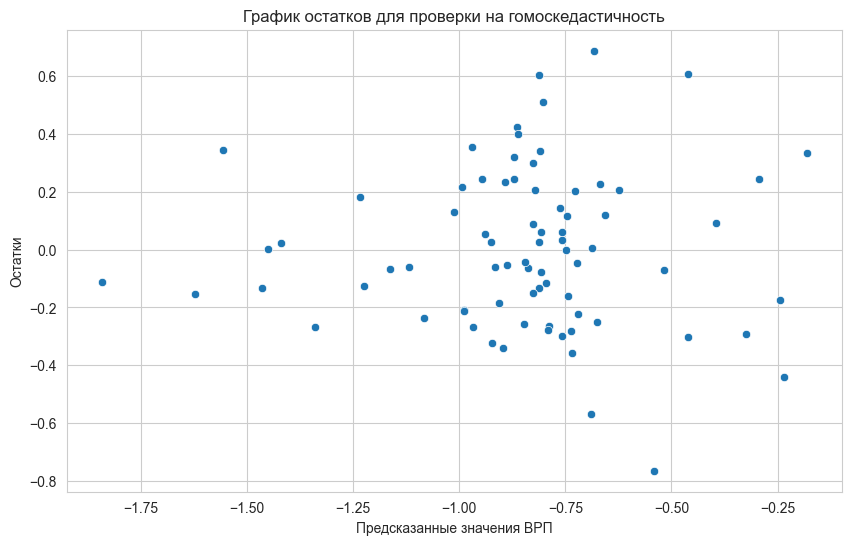

In [82]:
labels = ['Test Statistic', 'Test Statistic p-value', 'F-Statistic', 'F-Test p-value']
white_test = het_white(model.resid, model.model.exog)
print(dict(zip(labels, white_test)))

fitted_vals = model.fittedvalues # предсказания у
residuals = model.resid # остатки

plt.figure(figsize=(10, 6))
sns.scatterplot(x=fitted_vals, y=residuals)
plt.xlabel('Предсказанные значения ВРП')
plt.ylabel('Остатки')
plt.title('График остатков для проверки на гомоскедастичность')
plt.show()

Так как полученное p-значение p = 0,07 превышает уровень значимости 0,05, у нас нет оснований отвергнуть нулевую гипотезу. Следовательно, гетероскедастичность в модели не обнаружена, и остатки можно считать гомоскедастичными.

Проверим модель с помощью RESET-теста

In [83]:
reset_test = oi.reset_ramsey(model, degree=3)
print("ТЕСТ РАМСЕЯ:")
print(f"F-статистика: {float(reset_test.fvalue):.4f}")
print(f"p-value: {float(reset_test.pvalue):.4f}")

ТЕСТ РАМСЕЯ:
F-статистика: 0.8194
p-value: 0.4448


Результаты теста Рамсея (RESET) показывают, что p-значение равно 0,4448, что значительно выше любого общепринятого уровня значимости (0,05). Следовательно, у нас нет оснований отвергать нулевую гипотезу. Это означает, что спецификация модели является адекватной и в ней отсутствуют существенные пропущенные переменные или неправильный функциональный вид.

А также проверим остатки на нормальное распределениe по тесту Харке - Бера.

In [84]:
name = ['Jarque-Bera', 'Chi^2 p-value']
test = sms.jarque_bera(model.resid)
print(dict(zip(name, test)))

{'Jarque-Bera': np.float64(0.40442820923018824), 'Chi^2 p-value': np.float64(0.8169200028739947)}


Так как полученное p-значение p = 0,82 что превышает уровень значимости 0,05, значит у нас нет оснований отвергнуть гипотезу H_0. Следовательно остатки распределены нормально.

Следовательно итоговая модель выглядит так:\
ln(y) = -1,4729 - 0,0321 * X1 + 0,0117 * X2 + 0,4454γ + ε\
Коэффициент детерминации: 0,55\
F-статистика: 29,59 > 3,1\
Критерий Акаике (AIC): 26,09\
Тест Уайта: 0,07 > 0,05\
Тест Харке - Бера: 0,82 > 0,05


In [85]:
df.to_csv('../data/df_final_with_dummies.csv', index=False, encoding='utf-8-sig', sep=';')